In [ ]:
#### 绘图入门
https://matplotlib.org/

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
pd.options.display.max_rows = 10
anscombe = sns.load_dataset("anscombe") # 加载 Anscombe 数据集

In [3]:
anscombe.head()

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


In [4]:
anscombe.groupby('dataset').std()

,x,y
dataset,,
I,3.316625,2.031568
II,3.316625,2.031657
III,3.316625,2.030424
IV,3.316625,2.030579


In [5]:
anscombe['dataset'].value_counts()

II     11
IV     11
I      11
III    11
Name: dataset, dtype: int64

In [6]:
# 提取dataset I
ds_1 = anscombe[anscombe['dataset'] == 'I']

In [7]:
ds_1

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33
...,...,...,...
6,I,6.0,7.24
7,I,4.0,4.26
8,I,12.0,10.84
9,I,7.0,4.82


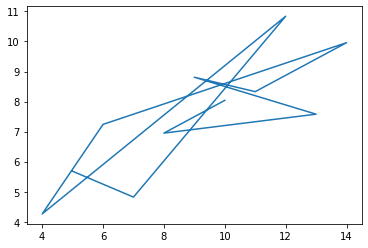

In [8]:
# plot ds_1
plt.plot(ds_1['x'], ds_1['y'])

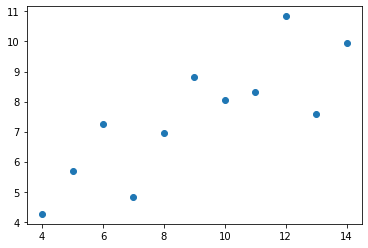

In [9]:
# 画点
plt.plot(ds_1['x'], ds_1['y'], 'o')

In [10]:
ds_2 = anscombe[anscombe['dataset'] == 'II']
ds_3 = anscombe[anscombe['dataset'] == 'III']
ds_4 = anscombe[anscombe['dataset'] == 'IV']

##### 创建子图

In [ ]:
# 创建一个figure对象作为画布
fig = plt.figure()
#figure() 用来创建一个新的图形对象。图形对象可以包含一个或多个子图，允许你在同一个窗口或画布上绘制多个图。
type(fig)

matplotlib.figure.Figure

<Figure size 432x288 with 0 Axes>

In [12]:
# 子图有两行两列，axes1的位置是1
axes1 = fig.add_subplot(2, 2, 1)

In [13]:
# 分别给出axes2,axes3,axes4的位置
axes2 = fig.add_subplot(2, 2, 2)
axes3 = fig.add_subplot(2, 2, 3)
axes4 = fig.add_subplot(2, 2, 4)

In [14]:
# 分别在4个子图上绘图
axes1.plot(ds_1['x'], ds_1['y'], 'o')
axes2.plot(ds_2['x'], ds_2['y'], 'o')
axes3.plot(ds_3['x'], ds_3['y'], 'o')
axes4.plot(ds_4['x'], ds_4['y'], 'o')

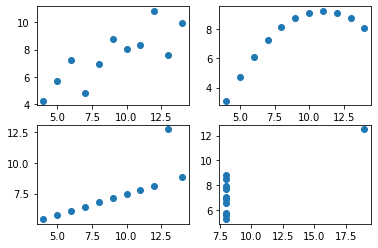

In [15]:
fig

In [16]:
# 向各幅子图添加小标题
axes1.set_title("dataset_1")
axes2.set_title("dataset_2")
axes3.set_title("dataset_3")
axes4.set_title("dataset_4")

Text(0.5, 1.0, 'dataset_4')

In [ ]:
# 向整幅图 添加一个总标题
fig.suptitle("Anscombe Data") # sup 是 "super" 的缩写，意思是“上面的”或“上层的”。

Text(0.5, 0.98, 'Anscombe Data')

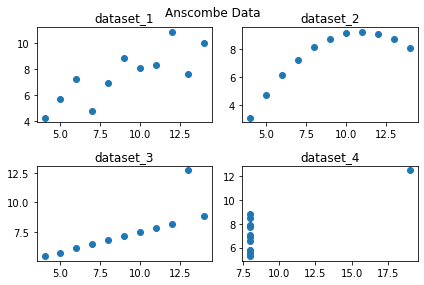

In [ ]:
# 使用紧凑布局，自动调整图形中的所有子图（subplot）的位置，使得它们之间的间距合适，避免标签、标题、刻度等元素重叠或被裁剪
fig.tight_layout()
fig

See more on [Parts of a Figure](http://matplotlib.org/faq/usage_faq.html#parts-of-a-figure)

#### 使用matplotlib绘图

In [19]:
tips = sns.load_dataset("tips")

In [20]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


##### 直方图

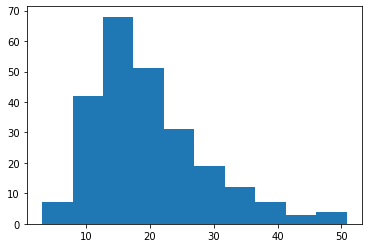

In [ ]:
fig = plt.figure() #创建一个新的图形对象（画布）
axes1 = fig.add_subplot(1, 1, 1)
axes1.hist(tips['total_bill'], bins=10) #把数据范围分成 10 个区间（bin）（统计堆栈）
plt.show()

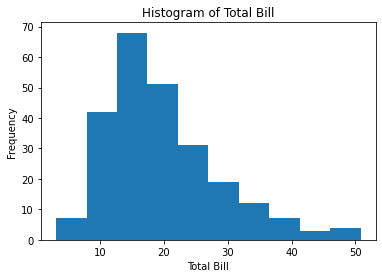

In [22]:
axes1.set_title('Histogram of Total Bill')
axes1.set_ylabel('Frequency')
axes1.set_xlabel('Total Bill')
fig

##### 散点图

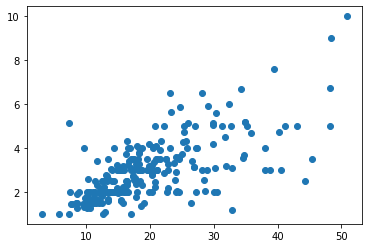

In [23]:
scatter_plot = plt.figure()
axes1 = scatter_plot.add_subplot(1, 1, 1)
axes1.scatter(tips['total_bill'], tips['tip']) #scatter plot需要两个变量

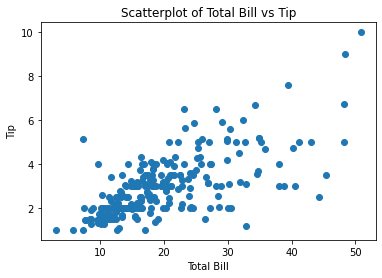

In [24]:
axes1.set_title('Scatterplot of Total Bill vs Tip')
axes1.set_xlabel('Total Bill')
axes1.set_ylabel('Tip')
scatter_plot

##### 箱线图

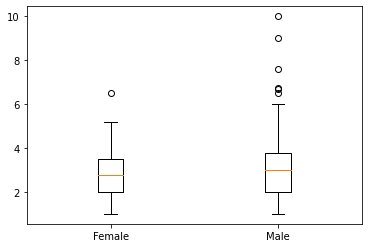

In [ ]:
boxplot = plt.figure()
axes1 = boxplot.add_subplot(1, 1, 1)
axes1.boxplot(
    [tips[tips['sex'] == 'Female']['tip'], 
     #  选出 tips 表中所有性别为 Female 的行，然后再取出 tip（小费）这一列
     tips[tips['sex'] == 'Male']['tip']],
    labels=['Female', 'Male'])
plt.show()

##### 图中中线为中位数，箱线上下为25%(Q1)和75%(Q3)分位数
##### 下横线是Q1 - 1.5*(Q3-Q1)，上横线Q3 + 1.5*(Q3-Q1)

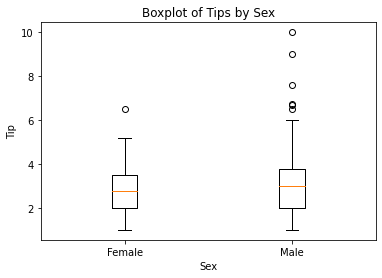

In [26]:
axes1.set_xlabel('Sex')
axes1.set_ylabel('Tip')
axes1.set_title('Boxplot of Tips by Sex')
boxplot

##### 多个变量关系

In [27]:
def recode_sex(sex):
    if sex == 'Female':
       return 0
    else:
       return 1

In [ ]:
tips['sex_color'] = tips['sex'].apply(recode_sex)
print(tips)
# apply（）：对某一列或某一行（dataframe）中的每个元素，应用一个函数（function）并返回结果。

     total_bill   tip     sex smoker   day    time  size sex_color
0         16.99  1.01  Female     No   Sun  Dinner     2         0
1         10.34  1.66    Male     No   Sun  Dinner     3         1
2         21.01  3.50    Male     No   Sun  Dinner     3         1
3         23.68  3.31    Male     No   Sun  Dinner     2         1
4         24.59  3.61  Female     No   Sun  Dinner     4         0
..          ...   ...     ...    ...   ...     ...   ...       ...
239       29.03  5.92    Male     No   Sat  Dinner     3         1
240       27.18  2.00  Female    Yes   Sat  Dinner     2         0
241       22.67  2.00    Male    Yes   Sat  Dinner     2         1
242       17.82  1.75    Male     No   Sat  Dinner     2         1
243       18.78  3.00  Female     No  Thur  Dinner     2         0

[244 rows x 8 columns]


Text(0, 0.5, 'Tip')

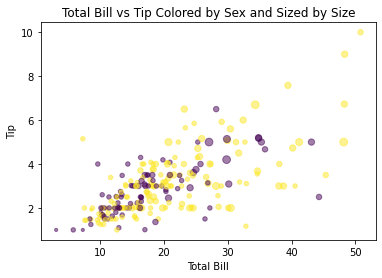

In [ ]:
scatter_plot = plt.figure()
axes1 = scatter_plot.add_subplot(1, 1, 1)
axes1.scatter(
    x=tips['total_bill'],
    y=tips['tip'],
    s=tips['size'] * 10, #设置点的大小。这里根据 size 列（聚会人数）来决定点的大小
    c=tips['sex_color'], #设置点的颜色
    alpha=0.5)
axes1.set_title('Total Bill vs Tip Colored by Sex and Sized by Size')
axes1.set_xlabel('Total Bill')
axes1.set_ylabel('Tip')

#### 使用seaborn画图
https://seaborn.pydata.org/

##### 直方图

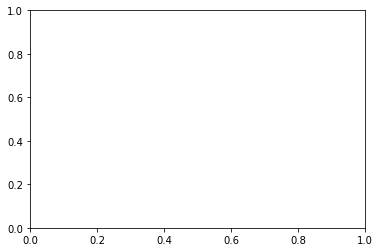

In [ ]:
hist, ax = plt.subplots()   #与plt.figure和add_subplot等价
# 用于一次性创建一个 图形对象（figure） 和一个或多个 子图（axes）
# fig, (ax1, ax2) = plt.subplots(1, 2)

Text(0.5, 1.0, 'Total Bill Histogram with Density Plot')

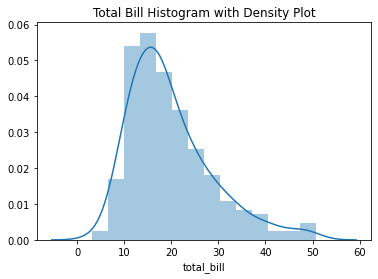

In [ ]:
ax = sns.distplot(tips['total_bill']) #绘制直方图，核密度估计（KDE）：以平滑曲线展示数据的概率密度函数（PDF）
ax.set_title('Total Bill Histogram with Density Plot')
# distplot() 函数已被弃用，显示为删除线。
#使用 sns.histplot() 来绘制直方图。
# sns.kdeplot() 来绘制核密度估计（KDE）。
#sns.histplot(tips['total_bill'], kde=True) 并通过 kde=True 绘制密度图

Text(0, 0.5, 'Frequency')

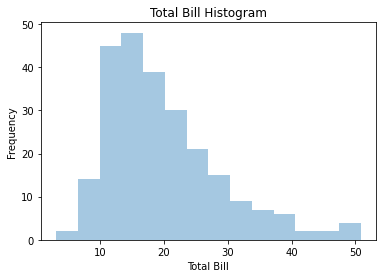

In [32]:
hist, ax = plt.subplots()
ax = sns.distplot(tips['total_bill'], kde=False)  #去掉核密度估计
ax.set_title('Total Bill Histogram')
ax.set_xlabel('Total Bill')
ax.set_ylabel('Frequency')

##### 核密度估计

Text(0, 0.5, 'Unit Probability')

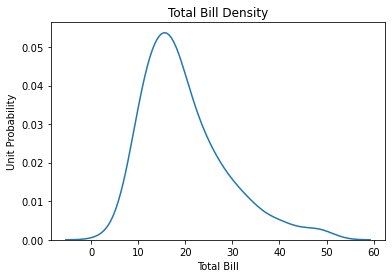

In [33]:
den, ax = plt.subplots()
ax = sns.distplot(tips['total_bill'], hist=False)  #去掉直方图
ax.set_title('Total Bill Density')
ax.set_xlabel('Total Bill')
ax.set_ylabel('Unit Probability')

##### 频数图

Text(0.5, 0, 'Total Bill')

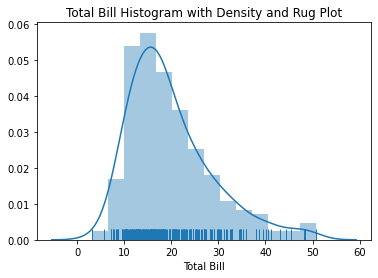

In [ ]:
hist_den_rug, ax = plt.subplots()
ax = sns.distplot(tips['total_bill'], rug=True)
#地毯图（rug plot） 是一种显示数据分布的方式，它在每个数据点的下方绘制短线，帮助展示数据的分布位置。
ax.set_title('Total Bill Histogram with Density and Rug Plot')
ax.set_xlabel('Total Bill')

##### 计数图(条形图)

Text(0, 0.5, 'Frequency')

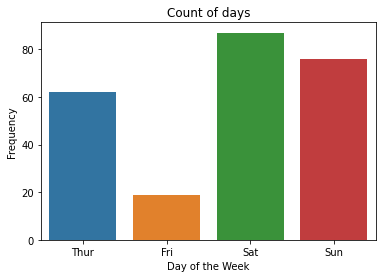

In [ ]:
count, ax = plt.subplots()

ax = sns.countplot('day', data=tips) #要统计的分类变量 ；使用的数据表

ax.set_title('Count of days')
ax.set_xlabel('Day of the Week')
ax.set_ylabel('Frequency')

Text(0, 0.5, 'Frequency')

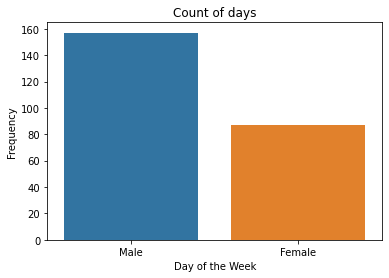

In [ ]:
count, ax = plt.subplots()

ax = sns.countplot(tips['sex']) # 另一种写法

ax.set_title('Count of days')
ax.set_xlabel('Day of the Week')
ax.set_ylabel('Frequency')

##### 散点图

Text(0, 0.5, 'Tip')

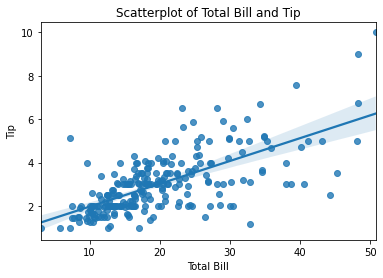

In [ ]:
scatter, ax = plt.subplots()

ax = sns.regplot(x='total_bill', y='tip', data=tips) #绘制了 回归图（regression plot）
# data=tips：指定数据来源为 tips 数据集。 推荐写法

ax.set_title('Scatterplot of Total Bill and Tip')
ax.set_xlabel('Total Bill')
ax.set_ylabel('Tip')

Text(0, 0.5, 'Tip')

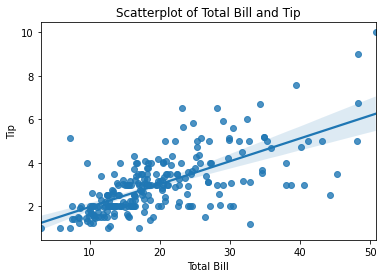

In [ ]:
scatter, ax = plt.subplots()

ax = sns.regplot(x=tips['total_bill'], y=tips['tip']) # 另一种写法(不推荐)

ax.set_title('Scatterplot of Total Bill and Tip')
ax.set_xlabel('Total Bill')
ax.set_ylabel('Tip')

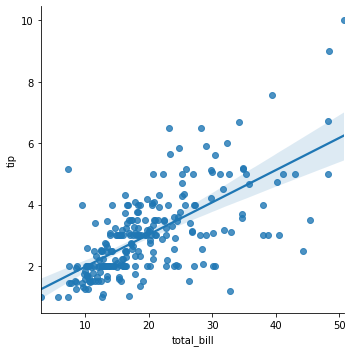

In [ ]:
fig = sns.lmplot(x='total_bill', y='tip', data=tips)  #lmplot创建figure，而regplot创建一个axes
# Linear Model Plot，即 线性模型图。

Text(0.5, 1.03, 'Joint Plot of Total Bill and Tip')

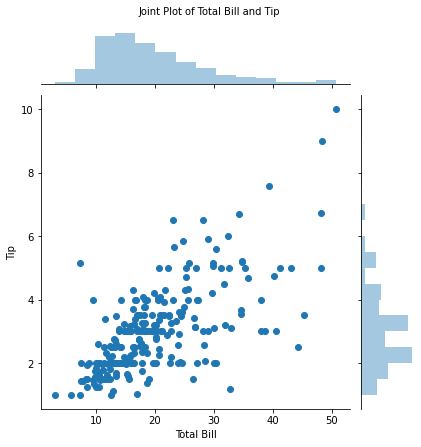

In [ ]:
joint = sns.jointplot(x='total_bill', y='tip', data=tips)  #联合分布图jointplot同样创建一个figure

joint.set_axis_labels(xlabel='Total Bill', ylabel='Tip') #显示每个变量的分布以及它们的相关性
joint.fig.suptitle('Joint Plot of Total Bill and Tip',fontsize=10, y=1.03) #font字体
# y=1.03：调整标题的位置，使其稍微高于默认位置，避免与其他内容重叠

##### 蜂巢图

Text(0.5, 1.03, 'Hexbin Joint Plot of Total Bill and Tip')

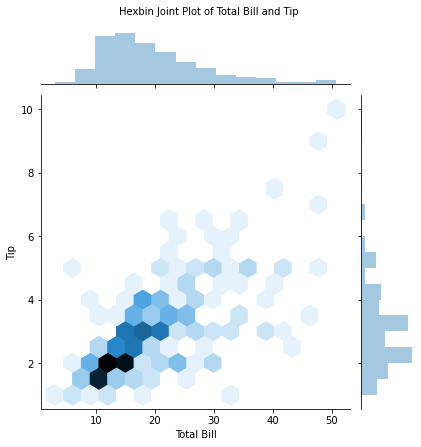

In [ ]:
hexbin = sns.jointplot(x="total_bill", y="tip", data=tips, kind="hex")
# hexagon六边形
hexbin.set_axis_labels(xlabel='Total Bill', ylabel='Tip')
hexbin.fig.suptitle('Hexbin Joint Plot of Total Bill and Tip', fontsize=10, y=1.03)

##### 2维核密度图

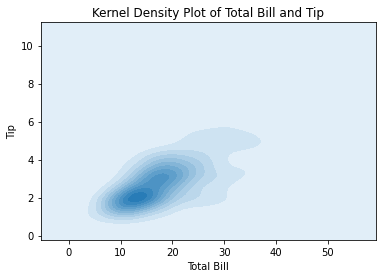

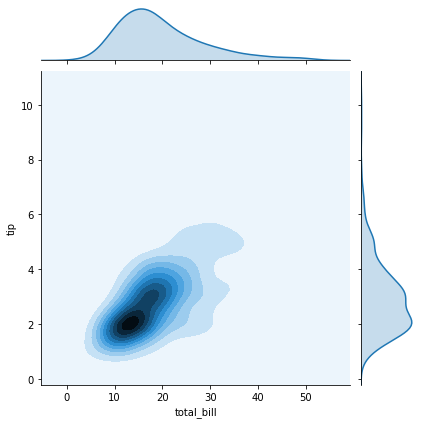

In [ ]:
kde, ax = plt.subplots()
ax = sns.kdeplot(data=tips['total_bill'],
                 data2=tips['tip'], # 老版写法
                 shade=True) #  shade=True	将密度曲线下的区域填充颜色，更直观
# sns.kdeplot(x=tips['total_bill'], y=tips['tip'], shade=True) 新版写法

ax.set_title('Kernel Density Plot of Total Bill and Tip')
ax.set_xlabel('Total Bill')
ax.set_ylabel('Tip')
plt.show()

kde_joint = sns.jointplot(x='total_bill', y='tip', data=tips, kind='kde')

##### 条形图

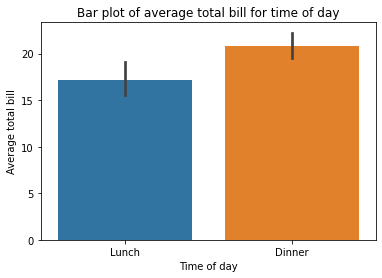

In [ ]:
bar, ax = plt.subplots()

ax = sns.barplot(x='time', y='total_bill', data=tips)  #默认计算total_bill的均值

ax.set_title('Bar plot of average total bill for time of day')
ax.set_xlabel('Time of day')
ax.set_ylabel('Average total bill') # 平均值
plt.show() #显示误差线（默认是 95% 的置信区间）。

##### 箱线图

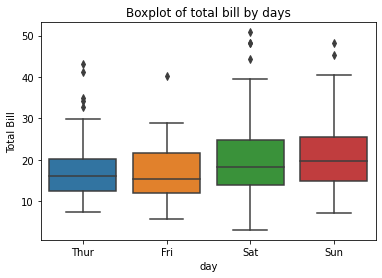

In [ ]:
box, ax = plt.subplots()

ax = sns.boxplot(x='day', y='total_bill', data=tips)

ax.set_title('Boxplot of total bill by days')
ax.set_xlabel('day')
ax.set_ylabel('Total Bill')
plt.show()

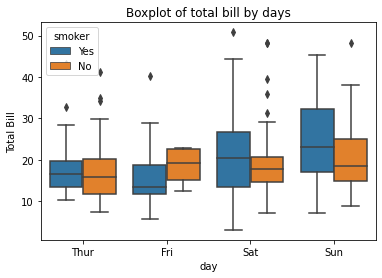

In [ ]:
box, ax = plt.subplots() #带有分组（hue）的箱线图 用不同颜色来区分不同类别

ax = sns.boxplot(x='day', y='total_bill', hue='smoker', data=tips)

ax.set_title('Boxplot of total bill by days')
ax.set_xlabel('day')
ax.set_ylabel('Total Bill')
plt.show()

##### 小提琴图

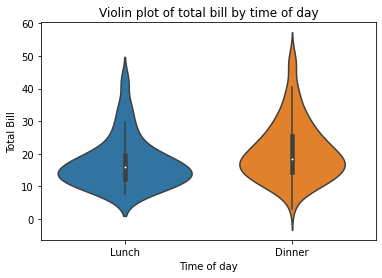

In [ ]:
violin, ax = plt.subplots()

ax = sns.violinplot(x='time', y='total_bill', data=tips)

ax.set_title('Violin plot of total bill by time of day')
ax.set_xlabel('Time of day')
ax.set_ylabel('Total Bill')
plt.show()

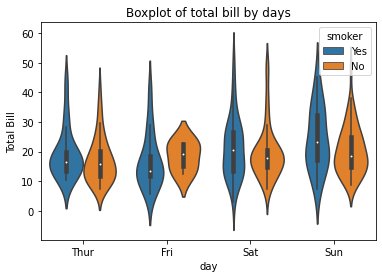

In [ ]:
box, ax = plt.subplots()

ax = sns.violinplot(x='day', y='total_bill', hue='smoker', data=tips)

ax.set_title('Boxplot of total bill by days')
ax.set_xlabel('day')
ax.set_ylabel('Total Bill')
plt.show()

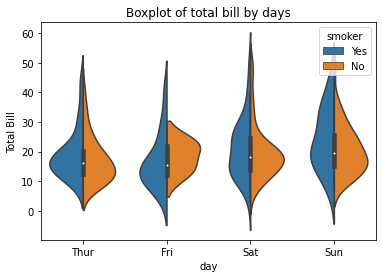

In [ ]:
box, ax = plt.subplots()

ax = sns.violinplot(x='day', y='total_bill', hue='smoker', data=tips, split=True)
#split=True将提琴图一分为二，左右各一边代表一个 hue 类别（吸烟者 vs 非吸烟者）

ax.set_title('Boxplot of total bill by days')
ax.set_xlabel('day')
ax.set_ylabel('Total Bill')
plt.show()

##### 成对关系

In [ ]:
tips_numeric = tips.iloc[:,0:-1] #去掉最后一列
# 使用 iloc 按 位置索引选择：所有行（:），从第 0 列到倒数第 2 列
tips_numeric

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


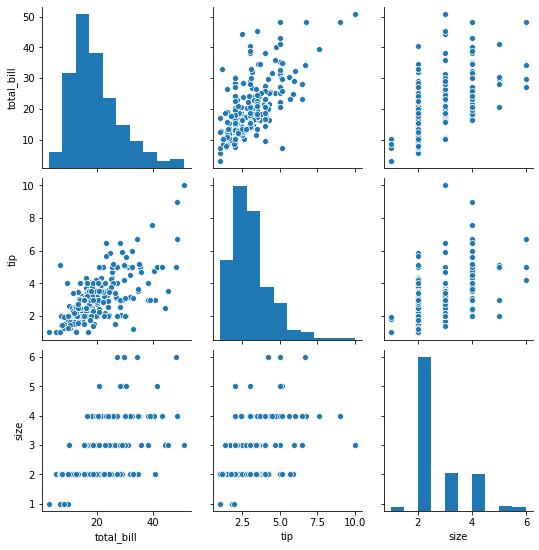

In [ ]:
sns.pairplot(tips_numeric)    #成对变量关系图 ，作用是一次性查看多个变量两两之间的关系。
# total_bill,tip,size之间的关系 3*3

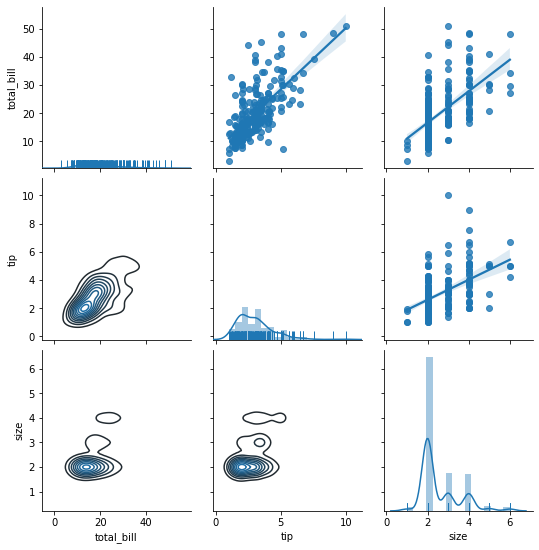

In [ ]:
pair_grid = sns.PairGrid(tips_numeric) #变量之间关系的图矩阵（PairGrid）
# 支持对 不同子图（对角线、上三角、下三角）应用不同图类型。
pair_grid = pair_grid.map_upper(sns.regplot) #上三角区域（上方的格子）为带回归线的散点图（sns.regplot）
pair_grid = pair_grid.map_lower(sns.kdeplot) # 下三角区域为 核密度图（KDE）
pair_grid = pair_grid.map_diag(sns.distplot, rug=True) #对角线
plt.show()

##### 多变量数据

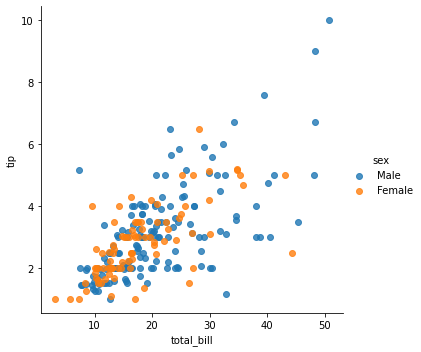

In [ ]:
scatter = sns.lmplot(x='total_bill', y='tip', data=tips,hue='sex', fit_reg=False)
# fit_reg=False	 不显示回归线，只画纯散点图
plt.show()  #使用hue参数得到total_bill, tip 和sex之间的关系
#sns.scatterplot()

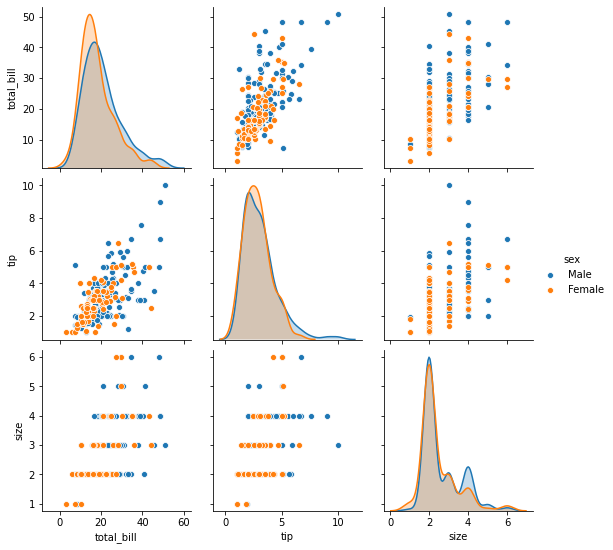

In [55]:
fig = sns.pairplot(tips_numeric, hue='sex')

##### 分面(facet)

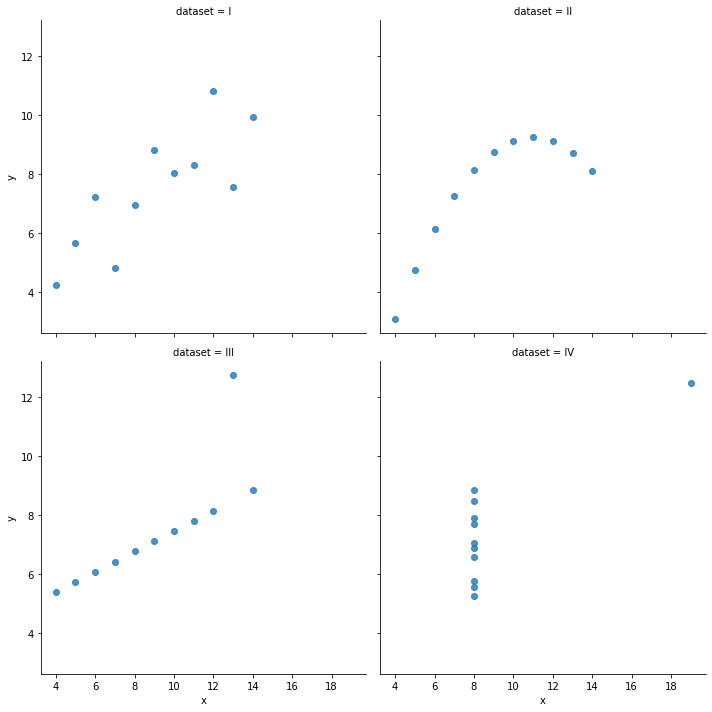

In [ ]:
anscombe_plot = sns.lmplot(x='x', y='y', data=anscombe,
                          fit_reg=False, col='dataset', col_wrap=2)  
# col='dataset'	按 dataset 列的值（I, II, III, IV）进行分图（即一组一图）
# col_wrap=2	每行显示 2 个图（自动换行） "column wrap"，意思是 列换行。
# wrap 换行

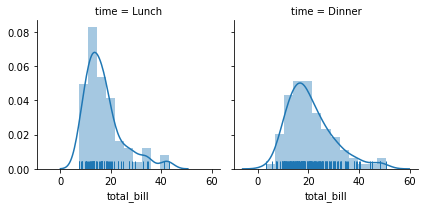

In [ ]:
facet = sns.FacetGrid(tips, col='time') # 将数据集分面
facet.map(sns.distplot, 'total_bill', rug=True)
# map() 函数应用 sns.distplot() 到每个子图的 total_bill 上。
plt.show()

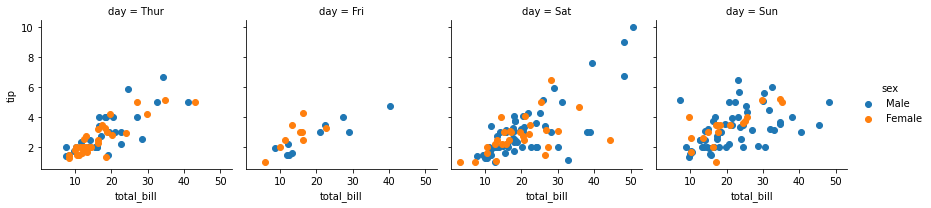

In [69]:
facet = sns.FacetGrid(tips, col='day', hue='sex') #还可以加上hue参数
facet = facet.map(plt.scatter, 'total_bill', 'tip')
facet = facet.add_legend()  #加上图例
plt.show()

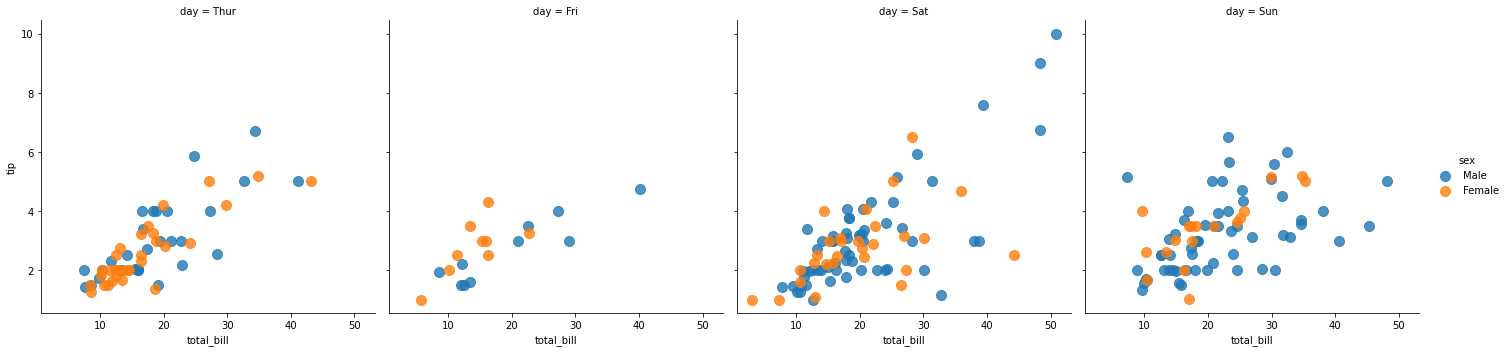

In [ ]:
fig = sns.lmplot(x='total_bill', y='tip', data=tips, fit_reg=False, hue='sex', col='day',scatter_kws={'s': 100})
# scatter_kws={'s': 100}	调整散点的大小 (s 是散点的大小，默认是 20，设置为 100 使散点变大)
# kws 是 keyword arguments（关键字参数）

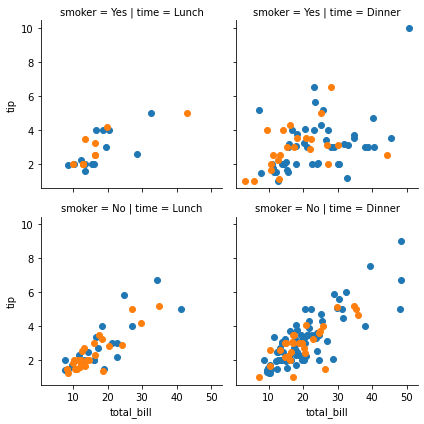

In [ ]:
facet = sns.FacetGrid(tips, col='time', row='smoker', hue='sex') #行和列表示不同的变量
facet.map(plt.scatter, 'total_bill', 'tip')
plt.show() #使用FacetGrid 来按多个分类变量（time、smoker 和 sex）创建网格分面，并在每个子图上绘制 散点图。

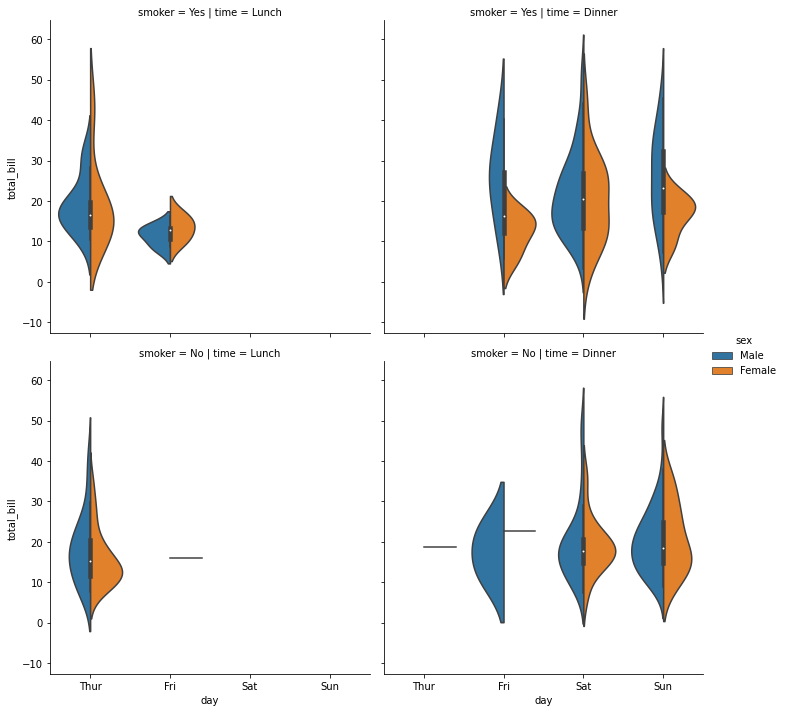

In [ ]:
facet = sns.catplot(x='day', y='total_bill', hue='sex', data=tips, row='smoker', col='time', kind='violin', split=True)
# 分类数据图（Categorical Plot）
# catplot 是用于绘制分类数据关系的通用接口，支持多种类型的分类图

#### 使用pandas进行绘图

##### 直方图

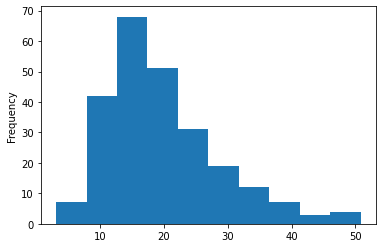

In [73]:
fig, ax = plt.subplots()
ax = tips['total_bill'].plot.hist()
plt.show()

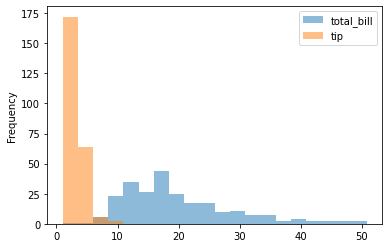

In [74]:
fig, ax = plt.subplots()
ax = tips[['total_bill', 'tip']].plot.hist(alpha=0.5, bins=20, ax=ax)
plt.show()

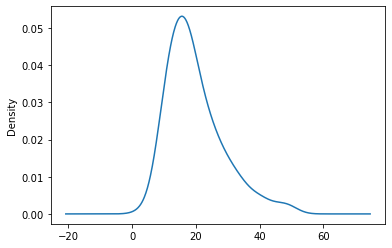

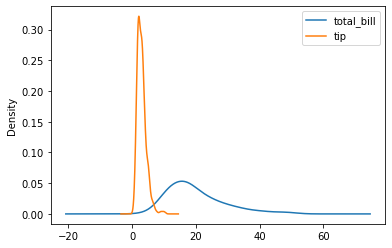

In [75]:
# on a series
fig, ax = plt.subplots()
ax = tips['total_bill'].plot.kde()
plt.show()

# on a dataframe
fig, ax = plt.subplots()
ax = tips[['total_bill', 'tip']].plot.kde(ax=ax)
plt.show()

##### 散点图

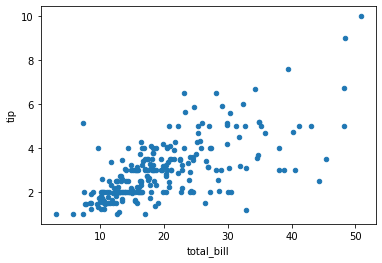

In [76]:
fig, ax = plt.subplots()
ax = tips.plot.scatter(x='total_bill', y='tip', ax=ax)
plt.show()

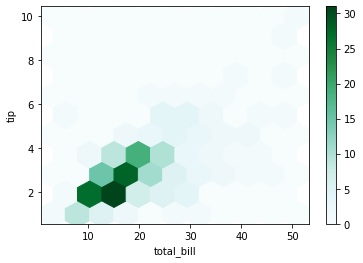

In [77]:
#蜂巢图
fig, ax = plt.subplots()
ax = tips.plot.hexbin(x='total_bill', y='tip', gridsize=10, ax=ax)
plt.show()

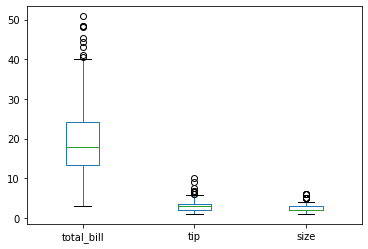

In [78]:
#箱线图
fig, ax = plt.subplots()
ax = tips.plot.box(ax=ax)
plt.show()

#### seaborn主题和样式

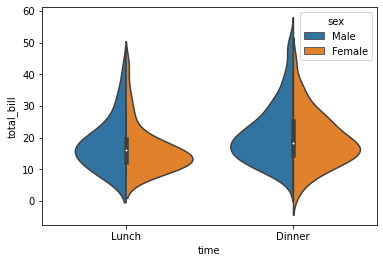

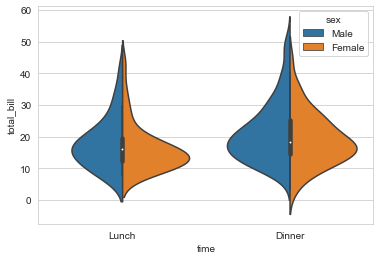

In [ ]:
fig, ax = plt.subplots()
ax = sns.violinplot(x='time', y='total_bill', hue='sex', data=tips, split=True)
plt.show()

# set style and plot
sns.set_style('whitegrid')  #writegrid样式 设置图表背景风格
fig, ax = plt.subplots()
ax = sns.violinplot(x='time', y='total_bill', hue='sex', data=tips, split=True)
plt.show()

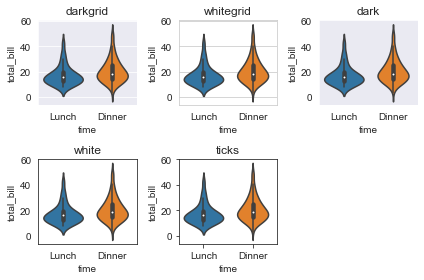

In [ ]:
fig = plt.figure()

seaborn_styles = ['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']

for idx, style in enumerate(seaborn_styles): #enumerate 列举、枚举
    # [(0, 'darkgrid'), (1, 'whitegrid'), (2, 'dark'), (3, 'white'), (4, 'ticks')]
    plot_position = idx + 1 
    with sns.axes_style(style):
# with 语句用于创建一个 上下文管理器，它让你在代码块内部应用某个样式，代码块执行完毕后，样式会自动恢复为原来的状态。
        ax = fig.add_subplot(2, 3, plot_position)
        violin = sns.violinplot(x='time', y='total_bill', data=tips, ax=ax)
        violin.set_title(style)

fig.tight_layout()
plt.show()